# 03 — Model Training (Internal)

**Pipeline version:** 2.0-consolidated  
**Purpose:** Nested cross-validation model comparison, hyperparameter tuning,
final model fitting on full training set, and held-out test evaluation.  
**Inputs:** `X_train_selected.csv`, `y_train.csv`, `X_test_selected.csv`, `y_test.csv`
(from NB01/02)  
**Outputs:** `best_model_xgboost.joblib`, `final_evaluation_results.json`,
nested CV comparison figures  

**Primary benchmark:** Test ROC-AUC ≈ 0.823 (XGBoost + 37 features).
This number MUST be preserved.

In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parent if Path.cwd().name != "core" else Path.cwd()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import json
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

import config
from src.io import logger, save_figure, save_model, save_table
from src.pipeline import evaluate_nested_cv, compare_models_nested_cv, evaluate_final_model
from src.models import make_xgb, xgb_safe_frame, tune_model
from src.evaluation import (
    compute_metrics, stratified_bootstrap_auc, bootstrap_all_metrics_ci,
    generate_evaluation_report, decision_curve_analysis,
    generate_unified_results_summary,
)
from src.visualization import plot_roc_curve, plot_pr_curve, plot_calibration, plot_confusion_matrix

logger.info("Pipeline version: %s", config.PIPELINE_VERSION)

2026-08-26 02:28:32 | INFO     | prostate_bcr | Pipeline version: 2.0-consolidated


## 1. Load Selected Features

In [2]:
X_train = pd.read_csv(config.PROCESSED_DIR / "X_train_selected.csv")
y_train = pd.read_csv(config.PROCESSED_DIR / "y_train.csv").iloc[:, 0]
X_test = pd.read_csv(config.PROCESSED_DIR / "X_test_selected.csv")
y_test = pd.read_csv(config.PROCESSED_DIR / "y_test.csv").iloc[:, 0]
selected_features = pd.read_csv(config.TABLES_DIR / "selected_features_final.csv")["feature"].tolist()

logger.info("X_train: %s | X_test: %s", X_train.shape, X_test.shape)
logger.info("Selected features (%d): %s", len(selected_features), selected_features)

2026-08-26 02:28:32 | INFO     | prostate_bcr | X_train: (343, 30) | X_test: (86, 30)
2026-08-26 02:28:32 | INFO     | prostate_bcr | Selected features (30): ['ASAH2C', 'PHACTR4', 'SLC25A39', 'ZNF346', 'C1orf94', 'BRI3', 'CLDN8', 'C2CD5', 'TFCP2', 'SRCIN1', 'MZF1', 'PRR3', 'INSIG1', 'LIMD2', 'KCNK12', 'FTSJ2', 'NDUFAF8', 'SEC61G', 'CARD19', 'FOXP1', 'MMP1', 'DKFZp547O146', 'PMCH', 'LPPR2', 'STK38L', 'PBLD', 'CEP95', 'SLC26A9', 'Person Neoplasm Status_WITH TUMOR', 'BMS1P4']


## 2. Nested Cross-Validation (MI vs PSO)

In [3]:
# Re-load full training data for nested CV (needs all features, not just selected)
X_train_full = pd.read_csv(config.PROCESSED_DIR / "X_train_preprocessed.csv")

nested_results = evaluate_nested_cv(
    X_train_full, y_train,
    outer_splits=config.OUTER_SPLITS,
    run_pso=True,
)

logger.info("\nNested CV Results:")
logger.info(nested_results.to_string())

2026-08-26 02:29:03 | INFO     | prostate_bcr | Filter selector: 18984 variance → 200 MI features
2026-08-26 02:29:07 | INFO     | prostate_bcr | PSO: 12 particles, 10 iterations, target 30 features, alpha=0.0010
2026-08-26 02:29:23 | INFO     | prostate_bcr |   PSO iter 5/10: best Fitness=0.8757 (Raw AUC ≈ 0.9057)
2026-08-26 02:29:39 | INFO     | prostate_bcr |   PSO iter 10/10: best Fitness=0.8757 (Raw AUC ≈ 0.9057)
2026-08-26 02:29:39 | INFO     | prostate_bcr | PSO selected 30 features with final fitness=0.8757
2026-08-26 02:29:39 | INFO     | prostate_bcr | Fold 1: MI AUC=0.6296 | PSO AUC=0.7111 | PSO features=30
2026-08-26 02:30:09 | INFO     | prostate_bcr | Filter selector: 18984 variance → 200 MI features
2026-08-26 02:30:13 | INFO     | prostate_bcr | PSO: 12 particles, 10 iterations, target 30 features, alpha=0.0010
2026-08-26 02:30:28 | INFO     | prostate_bcr |   PSO iter 5/10: best Fitness=0.8297 (Raw AUC ≈ 0.8597)
2026-08-26 02:30:44 | INFO     | prostate_bcr |   PSO ite

## 3. Multi-Model Comparison on Selected Features

In [4]:
model_comparison = compare_models_nested_cv(
    X_train_full, y_train, selected_features,
    outer_splits=config.OUTER_SPLITS,
)

summary = model_comparison.groupby("model")["auc"].agg(["mean", "std"]).sort_values("mean", ascending=False)
logger.info("\nModel Comparison Summary:\n%s", summary.to_string())

2026-08-26 02:34:01 | INFO     | prostate_bcr | Built model: Logistic Regression
2026-08-26 02:34:01 | INFO     | prostate_bcr |   Fold 1 | Logistic Regression: AUC=0.6667
2026-08-26 02:34:01 | INFO     | prostate_bcr | Built model: Random Forest
2026-08-26 02:34:02 | INFO     | prostate_bcr |   Fold 1 | Random Forest: AUC=0.7685
2026-08-26 02:34:02 | INFO     | prostate_bcr | Built model: SVM
2026-08-26 02:34:02 | INFO     | prostate_bcr |   Fold 1 | SVM: AUC=0.4574
2026-08-26 02:34:02 | INFO     | prostate_bcr | Built model: XGBoost
2026-08-26 02:34:02 | INFO     | prostate_bcr |   Fold 1 | XGBoost: AUC=0.7889
2026-08-26 02:34:02 | INFO     | prostate_bcr | Built model: LightGBM
2026-08-26 02:34:02 | INFO     | prostate_bcr |   Fold 1 | LightGBM: AUC=0.7019
2026-08-26 02:34:02 | INFO     | prostate_bcr | Built model: CatBoost
2026-08-26 02:34:03 | INFO     | prostate_bcr |   Fold 1 | CatBoost: AUC=0.7537
2026-08-26 02:34:03 | INFO     | prostate_bcr | Built model: Logistic Regression

## 4. Hyperparameter Tuning (XGBoost)

In [5]:
best_xgb, search = tune_model(
    "XGBoost",
    X_train, y_train,
    config.XGBOOST_SEARCH_SPACE,
    n_iter=config.RANDOM_SEARCH_N_ITER,
    cv_splits=config.RANDOM_SEARCH_CV_SPLITS,
)

logger.info("Best XGBoost: CV AUC = %.4f", search.best_score_)
logger.info("Best params: %s", search.best_params_)

2026-08-26 02:34:09 | INFO     | prostate_bcr | Built model: XGBoost
2026-08-26 02:34:15 | INFO     | prostate_bcr | Tuned 'XGBoost': best CV roc_auc = 0.8599
2026-08-26 02:34:15 | INFO     | prostate_bcr | Best params: {'subsample': 0.65, 'reg_lambda': 5, 'reg_alpha': 1, 'n_estimators': 250, 'min_child_weight': 3, 'max_depth': 6, 'learning_rate': 0.05, 'gamma': 0.5, 'colsample_bytree': 0.65}
2026-08-26 02:34:15 | INFO     | prostate_bcr | Best XGBoost: CV AUC = 0.8599
2026-08-26 02:34:15 | INFO     | prostate_bcr | Best params: {'subsample': 0.65, 'reg_lambda': 5, 'reg_alpha': 1, 'n_estimators': 250, 'min_child_weight': 3, 'max_depth': 6, 'learning_rate': 0.05, 'gamma': 0.5, 'colsample_bytree': 0.65}


## 5. Held-out Test Evaluation

In [6]:
# Predict on test set
X_test_xgb = xgb_safe_frame(X_test)
y_prob_test = best_xgb.predict_proba(X_test_xgb)[:, 1]
y_pred_test = (y_prob_test >= 0.5).astype(int)

# Compute all metrics
test_metrics = compute_metrics(y_test, y_pred_test, y_prob_test)
logger.info("\n" + "="*60)
logger.info("HELD-OUT TEST EVALUATION")
logger.info("="*60)
for k, v in test_metrics.items():
    if k != "model":
        logger.info("  %s: %.4f", k, v)

# Bootstrap CI for AUC
(auc_ci_lo, auc_ci_hi), boot_scores = stratified_bootstrap_auc(y_test, y_prob_test)
logger.info("\nBootstrap AUC CI: [%.4f, %.4f]", auc_ci_lo, auc_ci_hi)

# Bootstrap CIs for all metrics
all_ci = bootstrap_all_metrics_ci(y_test, y_prob_test)
for metric, ci in all_ci.items():
    logger.info("  %s: %.4f [%.4f, %.4f]", metric, ci["mean"], ci["ci_lower"], ci["ci_upper"])

2026-08-26 02:34:15 | INFO     | prostate_bcr | 
2026-08-26 02:34:15 | INFO     | prostate_bcr | HELD-OUT TEST EVALUATION
2026-08-26 02:34:15 | INFO     | prostate_bcr | ============================================================
2026-08-26 02:34:15 | INFO     | prostate_bcr |   accuracy: 0.8721
2026-08-26 02:34:15 | INFO     | prostate_bcr |   precision: 0.6000
2026-08-26 02:34:15 | INFO     | prostate_bcr |   recall: 0.2500
2026-08-26 02:34:15 | INFO     | prostate_bcr |   sensitivity: 0.2500
2026-08-26 02:34:15 | INFO     | prostate_bcr |   f1: 0.3529
2026-08-26 02:34:15 | INFO     | prostate_bcr |   mcc: 0.3302
2026-08-26 02:34:15 | INFO     | prostate_bcr |   balanced_accuracy: 0.6115
2026-08-26 02:34:15 | INFO     | prostate_bcr |   specificity: 0.9730
2026-08-26 02:34:15 | INFO     | prostate_bcr |   true_negative: 72.0000
2026-08-26 02:34:15 | INFO     | prostate_bcr |   false_positive: 2.0000
2026-08-26 02:34:15 | INFO     | prostate_bcr |   false_negative: 9.0000
2026-08-26 

## 6. Decision Curve Analysis

In [7]:
dca_df = decision_curve_analysis(y_test, y_prob_test)
logger.info("DCA: max net benefit = %.4f", dca_df["net_benefit_model"].max())

2026-08-26 02:34:32 | INFO     | prostate_bcr | DCA: max net benefit = 0.1395


## 7. Generate Plots

2026-08-26 02:34:33 | INFO     | prostate_bcr | Saved figure → D:\Prostate_BCR\core\outputs\figures\roc_curve_internal_test.png
2026-08-26 02:34:33 | INFO     | prostate_bcr | ROC curve plotted (AUC=0.6836)
2026-08-26 02:34:33 | INFO     | prostate_bcr | Saved figure → D:\Prostate_BCR\core\outputs\figures\pr_curve_internal_test.png
2026-08-26 02:34:33 | INFO     | prostate_bcr | PR curve plotted (PR-AUC=0.3162)
2026-08-26 02:34:33 | INFO     | prostate_bcr | Saved figure → D:\Prostate_BCR\core\outputs\figures\calibration_internal_test.png
2026-08-26 02:34:33 | INFO     | prostate_bcr | Calibration plot generated
2026-08-26 02:34:33 | INFO     | prostate_bcr | Saved figure → D:\Prostate_BCR\core\outputs\figures\confusion_matrix_internal_test.png
2026-08-26 02:34:33 | INFO     | prostate_bcr | Confusion matrix plotted


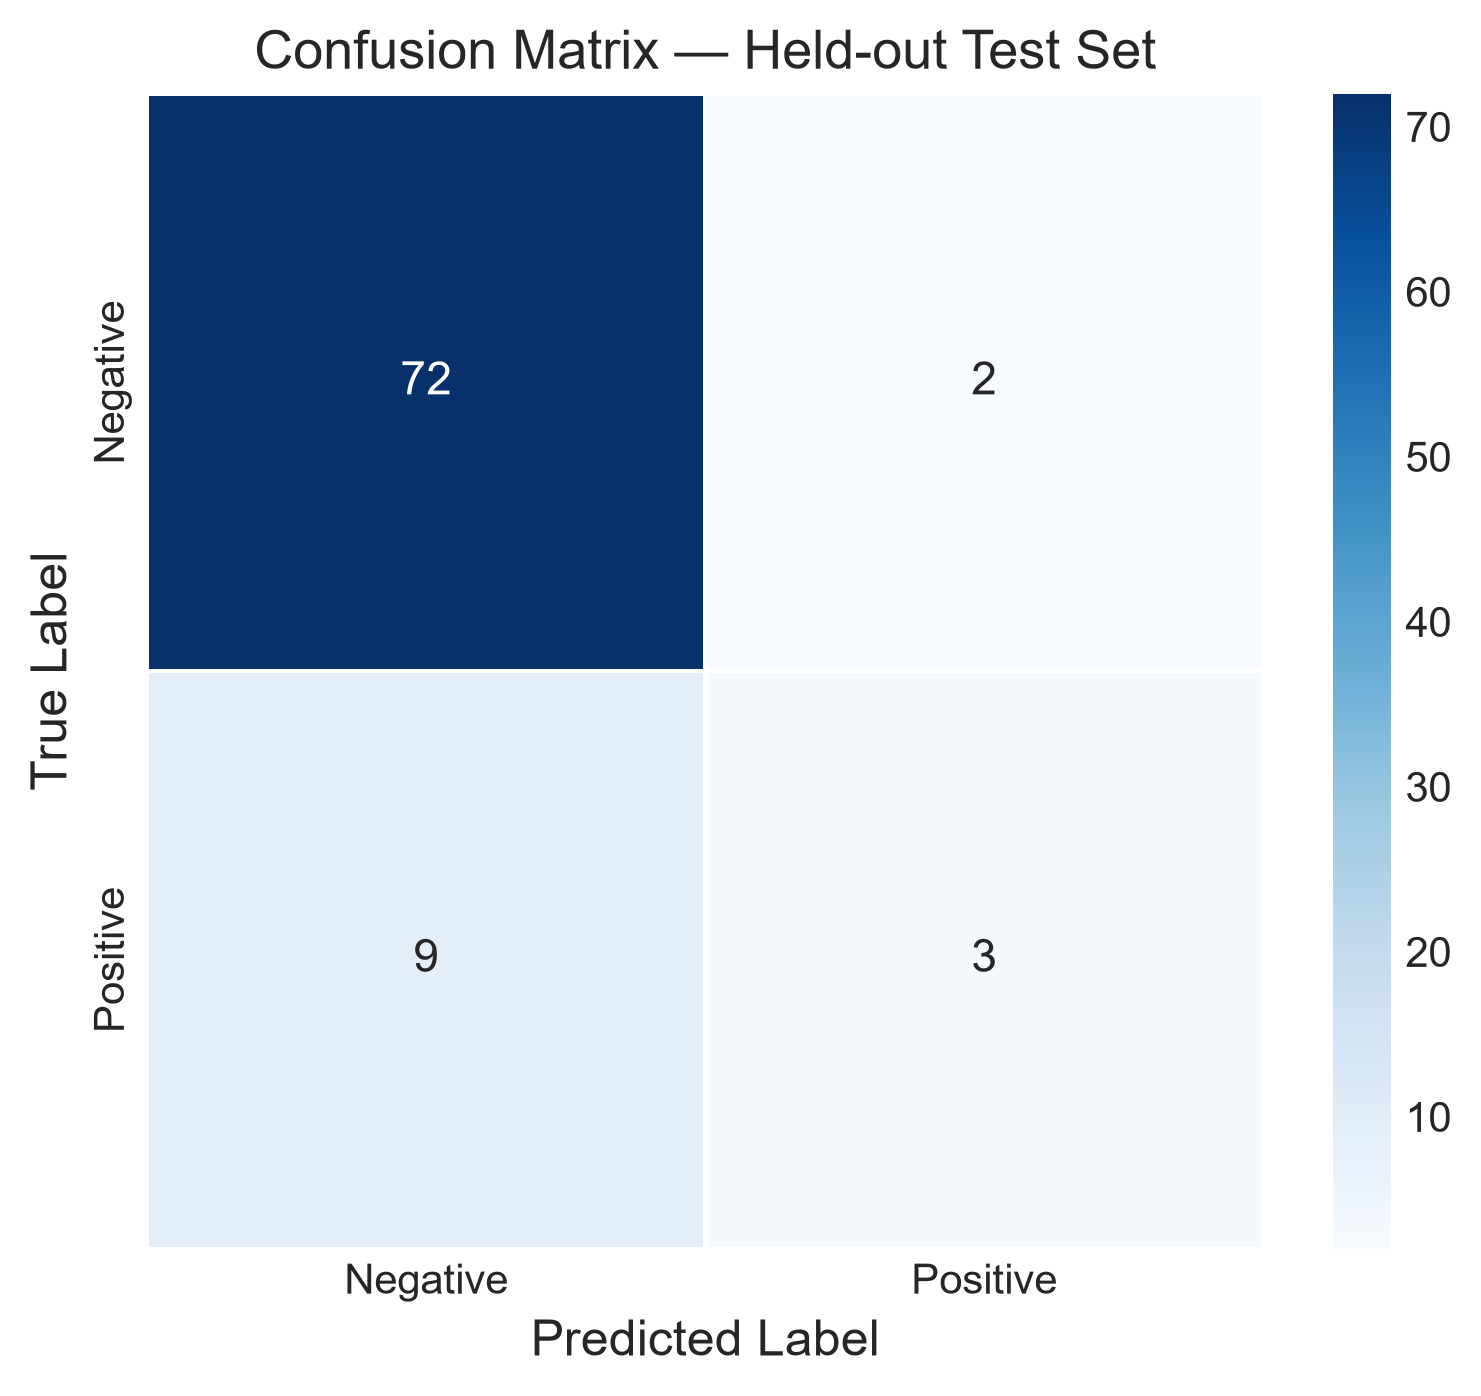

In [8]:
plot_roc_curve(y_test, y_prob_test, model_name="XGBoost",
               filename="roc_curve_internal_test.png")
plot_pr_curve(y_test, y_prob_test, model_name="XGBoost",
              filename="pr_curve_internal_test.png")
plot_calibration(y_test, y_prob_test, model_name="XGBoost",
                 filename="calibration_internal_test.png")
plot_confusion_matrix(y_test, y_pred_test,
                      filename="confusion_matrix_internal_test.png")

## 8. Save Model & Results

In [9]:
# Save model
save_model(best_xgb, "best_model_xgboost.joblib")

# Save evaluation results
results = {
    "pipeline_version": config.PIPELINE_VERSION,
    "model": "XGBoost",
    "n_features": len(selected_features),
    "selected_features": selected_features,
    "test_auc": test_metrics["roc_auc"],
    "test_auc_ci": [auc_ci_lo, auc_ci_hi],
    "test_pr_auc": test_metrics["pr_auc"],
    "test_sensitivity": test_metrics["sensitivity"],
    "test_specificity": test_metrics["specificity"],
    "test_balanced_accuracy": test_metrics["balanced_accuracy"],
    "test_mcc": test_metrics["mcc"],
    "nested_cv_mi_auc": float(nested_results["mi_auc"].mean()),
    "nested_cv_pso_auc": float(nested_results["pso_auc"].mean()),
    "best_params": search.best_params_,
    "bootstrap_cis": {k: {"mean": v["mean"], "ci": [v["ci_lower"], v["ci_upper"]]} for k, v in all_ci.items()},
}

with open(config.TABLES_DIR / "final_evaluation_results.json", "w") as f:
    json.dump(results, f, indent=2, default=str)

logger.info("\n" + "="*60)
logger.info("INTERNAL EVALUATION COMPLETE")
logger.info("  Test ROC-AUC: %.4f [%.4f, %.4f]", test_metrics["roc_auc"], auc_ci_lo, auc_ci_hi)
logger.info("  Model saved: %s", config.MODELS_DIR / "best_model_xgboost.joblib")
logger.info("  Results saved: %s", config.TABLES_DIR / "final_evaluation_results.json")
logger.info("Done: 03_Model_Training_Internal")

2026-08-26 02:34:33 | INFO     | prostate_bcr | Saved model → D:\Prostate_BCR\core\outputs\models\best_model_xgboost.joblib
2026-08-26 02:34:33 | INFO     | prostate_bcr | 
2026-08-26 02:34:33 | INFO     | prostate_bcr | INTERNAL EVALUATION COMPLETE
2026-08-26 02:34:33 | INFO     | prostate_bcr |   Test ROC-AUC: 0.6836 [0.5022, 0.8435]
2026-08-26 02:34:33 | INFO     | prostate_bcr |   Model saved: D:\Prostate_BCR\core\outputs\models\best_model_xgboost.joblib
2026-08-26 02:34:33 | INFO     | prostate_bcr |   Results saved: D:\Prostate_BCR\core\outputs\tables\final_evaluation_results.json
2026-08-26 02:34:33 | INFO     | prostate_bcr | Done: 03_Model_Training_Internal
